In [103]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
import json

In [104]:
SAMPLE_DIR = Path("samples/v3_1000/res_20250627_n100")

queries_labeled_df = pd.read_csv(SAMPLE_DIR / "_queries_labeled.csv")
responses_df = pd.read_csv(SAMPLE_DIR / "_responses.csv")
urls_pool_df = pd.read_csv(SAMPLE_DIR / "_urls_pool.csv")
classified_urls_df = pd.read_csv(SAMPLE_DIR / "__classified_urls.csv")
unclassified_urls_df = pd.read_csv(SAMPLE_DIR / "__unclassified_urls.csv")

In [105]:
print("Number of queries:", len(queries_labeled_df))
print("Number of AI Overviews triggered:", (queries_labeled_df["triggered_ai_overview"] == 'y').sum())
print("Number of pooled documents:", len(urls_pool_df))
print("Number of classified documents:", len(classified_urls_df))

Number of queries: 1000
Number of AI Overviews triggered: 409
Number of pooled documents: 35932
Number of classified documents: 24556


In [106]:
def plot_dist_pie(df, col, title=None):
    counts = df[col].value_counts(dropna=False)
    labels = [str(x) for x in counts.index]
    plt.figure(figsize=(4, 4))
    plt.pie(
        counts,
        labels=labels,
        autopct=lambda p: f'{p:.1f}%\n({int(round(p/100.*sum(counts)))})',
        startangle=140
    )
    plt.title(title or f"{col} distribution")
    plt.tight_layout()
    plt.show()

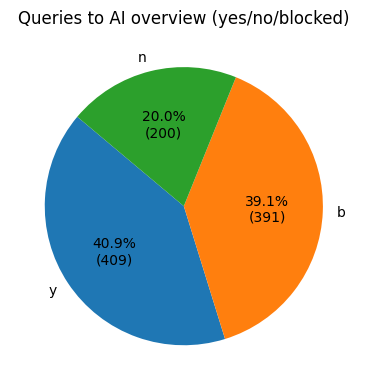

In [107]:
plot_dist_pie(queries_labeled_df, 'triggered_ai_overview', 'Queries to AI overview (yes/no/blocked)')

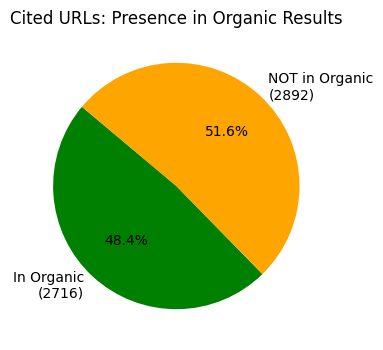

In [108]:
in_organic = 0
not_in_organic = 0

for _, row in responses_df.iterrows():
    try:
        refs = set(json.loads(row["references"]))
        organic = set(json.loads(row["organic_results"]))
    except Exception:
        continue

    for url in refs:
        if url in organic:
            in_organic += 1
        else:
            not_in_organic += 1

total = in_organic + not_in_organic
values = [in_organic, not_in_organic]
labels = [
    f"In Organic\n({in_organic})",
    f"NOT in Organic\n({not_in_organic})"
]

plt.figure(figsize=(4, 4))
plt.pie(
    values,
    labels=labels,
    autopct=lambda pct: f'{pct:.1f}%',
    colors=["green", "orange"],
    startangle=140
)
plt.title("Cited URLs: Presence in Organic Results")
plt.show()

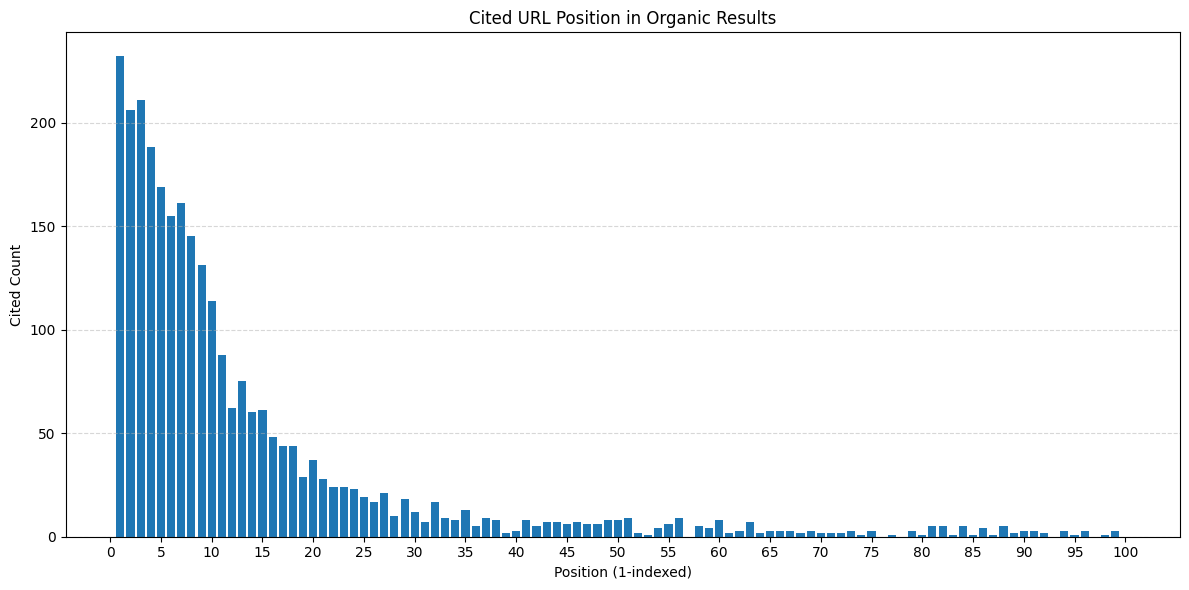

In [109]:
position_counter = Counter()

for _, row in responses_df.iterrows():
    try:
        refs = set(json.loads(row["references"]))
        organic = json.loads(row["organic_results"])
    except Exception:
        continue

    for i, url in enumerate(organic):
        if url in refs:
            position_counter[i + 1] += 1

positions = list(range(1, 101))
counts = [position_counter.get(i, 0) for i in positions]

plt.figure(figsize=(12, 6))
plt.bar(positions, counts)
plt.title("Cited URL Position in Organic Results")
plt.xlabel("Position (1-indexed)")
plt.ylabel("Cited Count")
plt.xticks(range(0, 101, 5))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [110]:
# Identify classified and unclassified
classified_set = set(classified_urls_df["url"])
pool_set = set(urls_pool_df["url"])

failed_to_classify = pool_set - classified_set

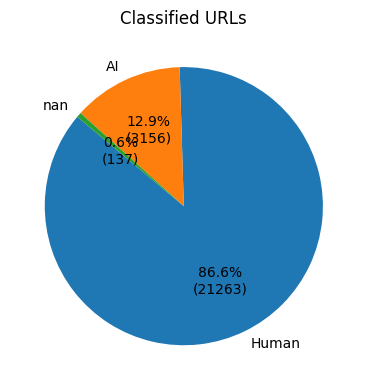

In [111]:
plot_dist_pie(classified_urls_df, 'ai_class', 'Classified URLs')

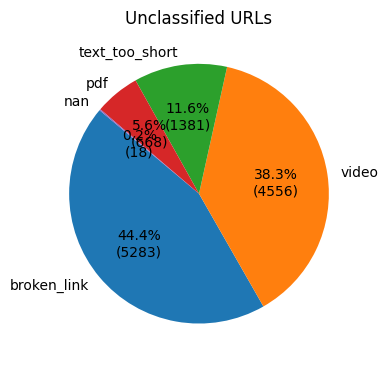

In [112]:
plot_dist_pie(unclassified_urls_df, 'category', 'Unclassified URLs')

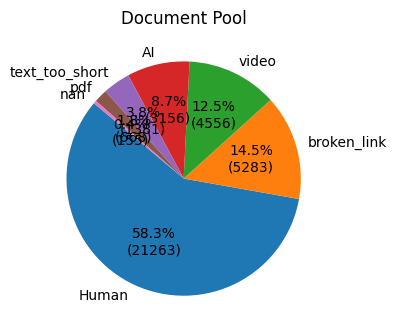

In [113]:
merged_df = pd.concat([
    classified_urls_df[['url']].assign(category=classified_urls_df['ai_class']),
    unclassified_urls_df[['url']].assign(category=unclassified_urls_df['category'])
], ignore_index=True)

plot_dist_pie(merged_df, 'category', 'Document Pool')

In [114]:
all_urls = set(urls_pool_df["url"])

# Define classified sets
ai_urls = set(classified_urls_df[classified_urls_df["ai_class"] == "AI"]["url"])
human_urls = set(classified_urls_df[classified_urls_df["ai_class"] == "Human"]["url"])
classified_urls = ai_urls | human_urls

# Define unclassified set
unclassified_urls = all_urls - classified_urls

# Collect cited URLs (refs ∩ organic)
cited_urls = set()
for _, row in responses_df.iterrows():
    try:
        refs = set(json.loads(row["references"]))
        organic = set(json.loads(row["organic_results"]))
        cited_urls.update(refs & organic)
    except Exception:
        continue

# Intersections
cited_ai = len(cited_urls & ai_urls)
cited_human = len(cited_urls & human_urls)
cited_unclassified = len(cited_urls & unclassified_urls)

total_ai = len(ai_urls)
total_human = len(human_urls)
total_unclassified = len(unclassified_urls)

# Probabilities
p_ai = cited_ai / total_ai if total_ai else 0
p_human = cited_human / total_human if total_human else 0
# p_unclassified = cited_unclassified / total_unclassified if total_unclassified else 0

# Output
print("P(cited | AI-generated):", f"{p_ai * 100:.2f}%")
print("P(cited | Human-written):", f"{p_human * 100:.2f}%")
# print("P(cited | Unclassified):", f"{p_unclassified * 100:.2f}%")

P(cited | AI-generated): 7.86%
P(cited | Human-written): 8.18%


In [115]:
# Step 1: Get all unclassified URLs labeled as 'video'
video_urls = {url for url in unclassified_urls if unclassified_category_map.get(url) == "video"}

# Step 2: Intersect with cited URLs
cited_video = len(cited_urls & video_urls)
total_video = len(video_urls)

# Step 3: Probability
p_video = cited_video / total_video if total_video else 0

# Output
print(f"P(cited | video): {p_video * 100:.2f}% ({cited_video}/{total_video})")


P(cited | video): 3.31% (151/4556)


In [116]:
# Probability of being cited *per organic document occurrence*

# Build lookup
ai_urls = set(classified_urls_df[classified_urls_df["ai_class"] == "AI"]["url"])
human_urls = set(classified_urls_df[classified_urls_df["ai_class"] == "Human"]["url"])

# Counters
ai_organic_count = 0
ai_cited_count = 0
human_organic_count = 0
human_cited_count = 0
total_organic_count = 0
total_cited_count = 0

# Add unclassified counters
unclassified_organic_count = 0
unclassified_cited_count = 0

for _, row in responses_df.iterrows():
    try:
        refs = set(json.loads(row["references"]))
        organic = json.loads(row["organic_results"])
    except Exception:
        continue

    for url in organic:
        total_organic_count += 1
        if url in refs:
            total_cited_count += 1

        if url in ai_urls:
            ai_organic_count += 1
            if url in refs:
                ai_cited_count += 1
        elif url in human_urls:
            human_organic_count += 1
            if url in refs:
                human_cited_count += 1
        else:
            unclassified_organic_count += 1
            if url in refs:
                unclassified_cited_count += 1

# Probabilities
p_overall = total_cited_count / total_organic_count if total_organic_count else 0
p_ai = ai_cited_count / ai_organic_count if ai_organic_count else 0
p_human = human_cited_count / human_organic_count if human_organic_count else 0
p_unclassified = unclassified_cited_count / unclassified_organic_count if unclassified_organic_count else 0

# Print
print("P(cited | appeared in organic):", f"{p_overall * 100:.2f}%")
print("P(cited | appeared in organic AND AI-classified):", f"{p_ai * 100:.2f}%")
print("P(cited | appeared in organic AND Human-classified):", f"{p_human * 100:.2f}%")
print("P(cited | appeared in organic AND Unclassified):", f"{p_unclassified * 100:.2f}%")


P(cited | appeared in organic): 3.39%
P(cited | appeared in organic AND AI-classified): 9.82%
P(cited | appeared in organic AND Human-classified): 8.80%
P(cited | appeared in organic AND Unclassified): 1.27%
